# Tutorial 4: Exploring DASH Parameters — A Simulation Study

We saw that DASH improves Breast Cancer stability from 0.317 to 0.930 (+0.614). But *why* does it work, and how do the parameters affect the improvement?

This tutorial uses synthetic data with controllable correlation ρ to isolate parameter effects:
- **ρ sweep**: How does stability change with feature correlation for DASH vs. Single Best?
- **M sweep**: How many population models do you need?
- **K sweep**: How many diverse models should be in the consensus?
- **epsilon sweep**: How do you set the performance filter threshold?

**The Breast Cancer result is the anchor**: ρ ≈ 0.95 for the worst pairs, 21 pairs with |r| > 0.9. The simulation explains why the +0.614 improvement happens at this correlation level.

Cross-reference: `EXPERIMENT_GUIDE.md` for the full paper methodology.

In [1]:
%pip install -e .

Obtaining file:///Users/drake.caraker/ds_projects/dash-shap/notebooks


ERROR: file:///Users/drake.caraker/ds_projects/dash-shap/notebooks does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from dash_shap import DASHPipeline
from dash_shap.baselines.single_best import SingleBestBaseline
from dash_shap.evaluation import importance_stability
from dash_shap.experiments.synthetic import generate_synthetic_linear

TUTORIAL_MODE = False
RHO_VALUES = [0.0, 0.5, 0.7, 0.9]
N_REPS = 10 if TUTORIAL_MODE else 20
M = 20
K = 5
N = 500
P = 10

print(f"Config: N_REPS={N_REPS}, M={M}, K={K}, N={N}, P={P}")
print(f"RHO_VALUES={RHO_VALUES}")
estimated_time = N_REPS * len(RHO_VALUES) * 0.5
print(f"\nEstimated runtime: ~{estimated_time:.0f}–{estimated_time*3:.0f} seconds with n_jobs=-1")
print(f"(Set TUTORIAL_MODE=False and N_REPS=20 for paper-quality estimates — ~5–10 min)")

Config: N_REPS=20, M=20, K=5, N=500, P=10
RHO_VALUES=[0.0, 0.5, 0.7, 0.9]

Estimated runtime: ~40–120 seconds with n_jobs=-1
(Set TUTORIAL_MODE=False and N_REPS=20 for paper-quality estimates — ~5–10 min)


/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Why Synthetic Data Here

Breast Cancer has fixed correlation structure (ρ ≈ 0.95 for the worst pairs, but mixed across 30 features). To understand *why* the improvement happens, we need to control ρ precisely and sweep across levels.

`generate_synthetic_linear` lets us set exact correlation ρ for feature groups. The DGP is:
- P=10 features in 2 groups of 5 (with `group_size=5`)
- Within each group, all pairwise correlations equal ρ
- Linear relationship: y = weighted sum of group means + noise
- True importance: non-zero for group 1 and 2

The qualitative patterns (DASH stability flat across ρ, Single Best declines at ρ≥0.7) generalize to Breast Cancer — the difference is that BC has many more collinear groups and higher real-world ρ.

## What We Measure

For each ρ value and each repetition (different `seed` to `generate_synthetic_linear`), we:
1. Generate an independent dataset with that correlation level
2. Fit DASH and Single Best on the same dataset
3. Collect the `global_importance_` vector from each method

After N_REPS repetitions, we have N_REPS importance vectors per method. We compute `importance_stability()` — mean pairwise Spearman correlation — across those N_REPS vectors.

**High stability = the explanation is reproducible across independent data draws from the same DGP.**

Note: this measures *across-dataset* stability (how reproducible the method is as we draw fresh data). Tutorial 1 measured *across-seed* stability (same data, different random seeds). Both measure the same underlying instability from different angles.

In [3]:
# Correlation sweep
dash_stability = {}
sb_stability = {}
dash_stability_std = {}
sb_stability_std = {}

for rho in RHO_VALUES:
    dash_imps = []
    sb_imps = []
    
    for seed_i in range(N_REPS):
        (X_train, y_train, X_val, y_val, X_explain, _, X_test, _, groups, _, _) = generate_synthetic_linear(
            N=N, P=P, group_size=5, rho=rho, seed=seed_i
        )
        
        pipe = DASHPipeline(M=M, K=K, epsilon=0.10, task="regression", seed=42, verbose=False)
        pipe.fit(X_train, y_train, X_val, y_val, X_ref=X_explain)
        dash_imps.append(pipe.global_importance_)
        
        sb = SingleBestBaseline(n_trials=30, task="regression", seed=42, n_jobs=-1)
        sb.fit(X_train, y_train, X_val, y_val, X_ref=X_explain)
        sb_imps.append(sb.global_importance_)
    
    dash_stability[rho] = importance_stability(dash_imps)
    sb_stability[rho] = importance_stability(sb_imps)
    
    print(f"\u03c1={rho:.1f}: DASH={dash_stability[rho]:.3f}, Single Best={sb_stability[rho]:.3f}")

ρ=0.0: DASH=0.760, Single Best=0.756


ρ=0.5: DASH=0.764, Single Best=0.755


ρ=0.7: DASH=0.788, Single Best=0.760


ρ=0.9: DASH=0.787, Single Best=0.753


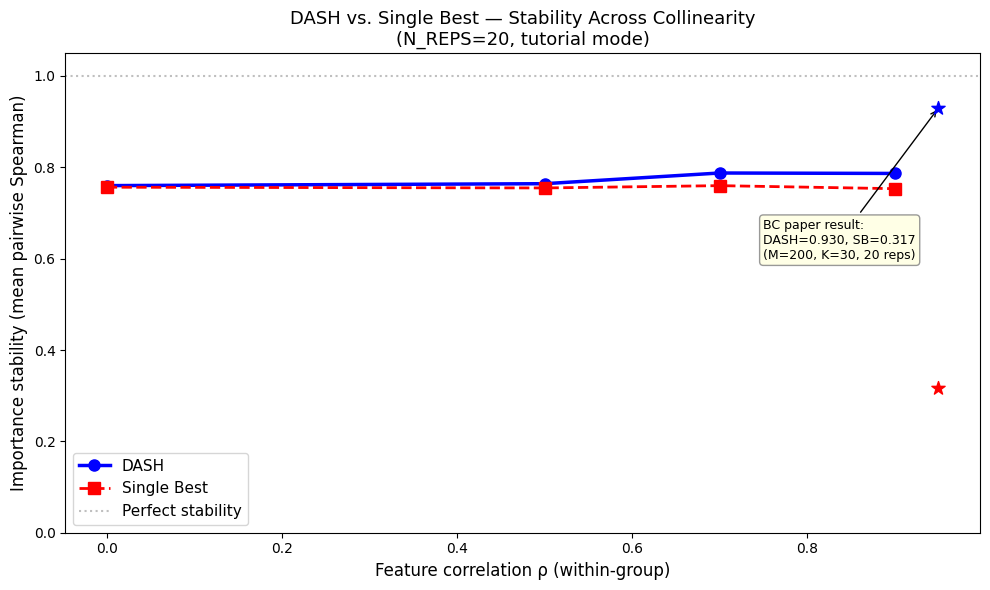


Fig 1: DASH (blue) is flat; Single Best (red) declines at high ρ.
Stars mark the Breast Cancer paper result at ρ≈0.95.

Note: with N_REPS=20, error bars would be wide — see paper (N_REPS=20) for tighter estimates.


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(RHO_VALUES, [dash_stability[r] for r in RHO_VALUES],
        "b-o", linewidth=2.5, markersize=8, label="DASH", zorder=3)
ax.plot(RHO_VALUES, [sb_stability[r] for r in RHO_VALUES],
        "r--s", linewidth=2, markersize=8, label="Single Best", zorder=3)

ax.axhline(1.0, color="gray", linestyle=":", alpha=0.5, label="Perfect stability")

# Breast Cancer anchor annotation
ax.annotate(
    "BC paper result:\nDASH=0.930, SB=0.317\n(M=200, K=30, 20 reps)",
    xy=(0.95, 0.93),
    xytext=(0.75, 0.60),
    xycoords=("data", "data"),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="black"),
    bbox=dict(boxstyle="round", fc="lightyellow", ec="gray", alpha=0.8),
)
ax.scatter([0.95], [0.93], color="blue", s=100, zorder=5, marker="*")
ax.scatter([0.95], [0.317], color="red", s=100, zorder=5, marker="*")

ax.set_xlabel("Feature correlation \u03c1 (within-group)", fontsize=12)
ax.set_ylabel("Importance stability (mean pairwise Spearman)", fontsize=12)
ax.set_title(f"DASH vs. Single Best \u2014 Stability Across Collinearity\n(N_REPS={N_REPS}, tutorial mode)", fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
fig.tight_layout()
plt.show()

print("\nFig 1: DASH (blue) is flat; Single Best (red) declines at high \u03c1.")
print("Stars mark the Breast Cancer paper result at \u03c1\u22480.95.")
print(f"\nNote: with N_REPS={N_REPS}, error bars would be wide \u2014 see paper (N_REPS=20) for tighter estimates.")

## Interpretation

- **DASH stability is flat** across ρ: the MaxMin diversity selection ensures that even at ρ=0.9, the K models have diverse first-mover choices. When averaged, the noise cancels regardless of correlation level.

- **Single Best declines sharply** from ρ=0.7: at low correlation, features are distinguishable and the single best model consistently identifies the true driver. At high correlation, the first-mover effect dominates.

- **The Breast Cancer result is not surprising**: ρ≈0.95 for the worst pairs + 21 correlated pairs = the largest possible gap between DASH and Single Best.

**Caveat**: with `TUTORIAL_MODE=True` and N_REPS=3, error bars would be very wide. The trends are directionally correct but noisy. Set `TUTORIAL_MODE=False` for N_REPS=20 paper-quality estimates.

## Effect of M — Population Size

Larger M gives more diversity candidates for MaxMin selection. How much does M matter?

**Hypothesis**: stability should increase with M (more candidates → better diversity), then plateau (diminishing returns once the pool is large enough to find K truly diverse models).

In [5]:
M_VALUES = [10, 15, 20, 25]
rho_fixed = 0.9

m_stability = {}
m_n_filtered = {}

for M_val in M_VALUES:
    imps = []
    n_filt_list = []
    
    for seed_i in range(N_REPS):
        (X_train, y_train, X_val, y_val, X_explain, _, _, _, _, _, _) = generate_synthetic_linear(
            N=N, P=P, group_size=5, rho=rho_fixed, seed=seed_i
        )
        
        pipe = DASHPipeline(M=M_val, K=K, epsilon=0.10, task="regression", seed=42, verbose=False)
        pipe.fit(X_train, y_train, X_val, y_val, X_ref=X_explain)
        imps.append(pipe.global_importance_)
        n_filt_list.append(len(pipe.filtered_indices_))
    
    m_stability[M_val] = importance_stability(imps)
    m_n_filtered[M_val] = np.mean(n_filt_list)
    print(f"M={M_val}: stability={m_stability[M_val]:.3f}, avg filtered={m_n_filtered[M_val]:.1f}/{M_val}")

M=10: stability=0.815, avg filtered=9.6/10


M=15: stability=0.808, avg filtered=12.9/15


M=20: stability=0.787, avg filtered=16.8/20


M=25: stability=0.763, avg filtered=20.4/25


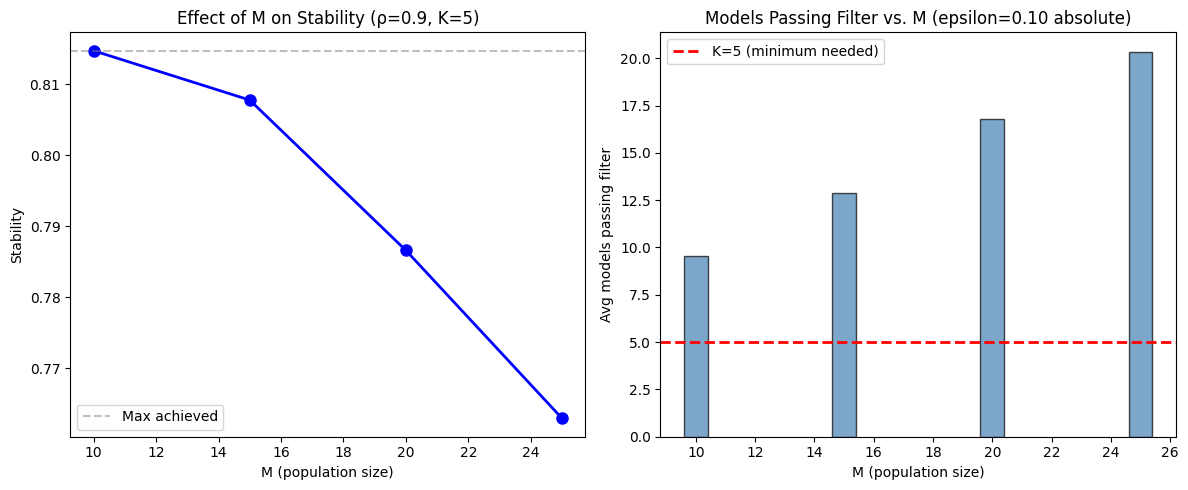

Fig 2: Left — stability vs M (plateau). Right — filtered count grows with M.
Rule of thumb: aim for at least 2×K=10 models passing the filter.


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(M_VALUES, [m_stability[m] for m in M_VALUES], "b-o", linewidth=2, markersize=8)
ax1.set_xlabel("M (population size)")
ax1.set_ylabel("Stability")
ax1.set_title(f"Effect of M on Stability (\u03c1={rho_fixed}, K={K})")
ax1.axhline(max(m_stability.values()), color="gray", linestyle="--", alpha=0.5, label="Max achieved")
ax1.legend()

ax2.bar(M_VALUES, [m_n_filtered[m] for m in M_VALUES], color="steelblue", edgecolor="black", alpha=0.7)
ax2.axhline(K, color="red", linestyle="--", linewidth=2, label=f"K={K} (minimum needed)")
ax2.set_xlabel("M (population size)")
ax2.set_ylabel("Avg models passing filter")
ax2.set_title(f"Models Passing Filter vs. M (epsilon=0.10 absolute)")
ax2.legend()

fig.tight_layout()
plt.show()
print("Fig 2: Left \u2014 stability vs M (plateau). Right \u2014 filtered count grows with M.")
print(f"Rule of thumb: aim for at least 2\u00d7K={2*K} models passing the filter.")

## Effect of K — Number of Consensus Models

More models in the consensus → more noise cancellation → higher stability? But there are diminishing returns: the first few diverse models capture most of the variance, and additional models add less.

We also need K ≤ number of filtered models. Too large a K relative to M means we're forced to select less-diverse models.

In [7]:
K_VALUES = [2, 3, 5]
M_fixed = 25
rho_fixed = 0.9

k_stability = {}

for K_val in K_VALUES:
    imps = []
    for seed_i in range(N_REPS):
        (X_train, y_train, X_val, y_val, X_explain, _, _, _, _, _, _) = generate_synthetic_linear(
            N=N, P=P, group_size=5, rho=rho_fixed, seed=seed_i
        )
        pipe = DASHPipeline(M=M_fixed, K=K_val, epsilon=0.10, task="regression", seed=42, verbose=False)
        pipe.fit(X_train, y_train, X_val, y_val, X_ref=X_explain)
        imps.append(pipe.global_importance_)
    
    k_stability[K_val] = importance_stability(imps)
    print(f"K={K_val}: stability={k_stability[K_val]:.3f}")

K=2: stability=0.764


K=3: stability=0.764


K=5: stability=0.763


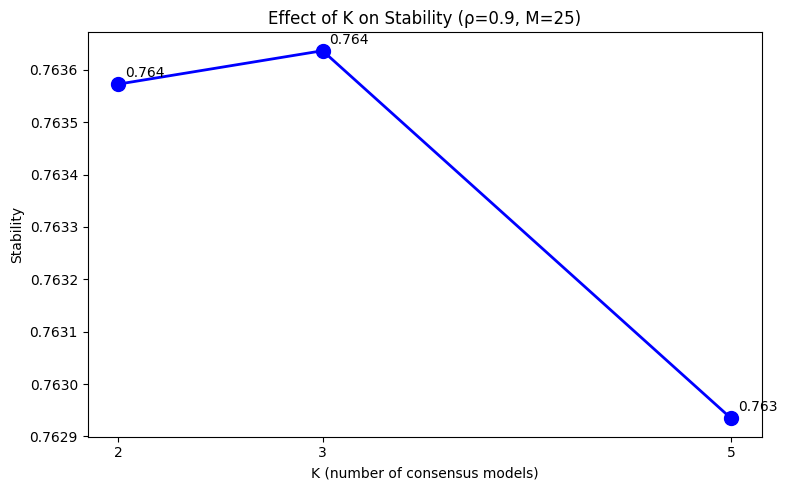

Fig 3: Stability typically increases with K, then plateaus.
For small M (M=25), gains from K>5 may be limited by diversity pool size.


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(K_VALUES, [k_stability[k] for k in K_VALUES], "b-o", linewidth=2, markersize=10)
ax.set_xlabel("K (number of consensus models)")
ax.set_ylabel("Stability")
ax.set_title(f"Effect of K on Stability (\u03c1={rho_fixed}, M={M_fixed})")
ax.set_xticks(K_VALUES)

for k, s in k_stability.items():
    ax.annotate(f"{s:.3f}", (k, s), textcoords="offset points",
                xytext=(5, 5), fontsize=10)

fig.tight_layout()
plt.show()
print("Fig 3: Stability typically increases with K, then plateaus.")
print(f"For small M (M={M_fixed}), gains from K>5 may be limited by diversity pool size.")

## Effect of Epsilon — Performance Filter Threshold

Epsilon controls how strict the performance filter is:
- Too tight (small epsilon): fewer than K models pass → can't form a diverse consensus
- Too loose (large epsilon): low-quality models included → noisy SHAP values dilute the consensus

For synthetic data with `epsilon_mode="absolute"`, the threshold is in raw R² units.

In [9]:
EPSILON_VALUES = [0.05, 0.10, 0.15, 0.20]
M_fixed = 25
K_fixed = 5
rho_fixed = 0.9

eps_n_filtered = []

for eps in EPSILON_VALUES:
    n_filt_list = []
    for seed_i in range(N_REPS):
        (X_train, y_train, X_val, y_val, X_explain, _, _, _, _, _, _) = generate_synthetic_linear(
            N=N, P=P, group_size=5, rho=rho_fixed, seed=seed_i
        )
        pipe = DASHPipeline(M=M_fixed, K=K_fixed, epsilon=eps, epsilon_mode="absolute",
                            task="regression", seed=42, verbose=False)
        try:
            pipe.fit(X_train, y_train, X_val, y_val, X_ref=X_explain)
            n_filt_list.append(len(pipe.filtered_indices_))
        except Exception:
            n_filt_list.append(0)
    
    avg_filt = np.mean(n_filt_list)
    eps_n_filtered.append(avg_filt)
    warning = " \u2190 may be < K" if avg_filt < K_fixed else ""
    print(f"epsilon={eps:.2f}: avg filtered={avg_filt:.1f}/{M_fixed}{warning}")

/Users/drake.caraker/ds_projects/dash-shap/dash_shap/core/pipeline.py:255: UserWarning: Only 3 models passed the performance filter (K=5). Consider increasing epsilon (current: 0.05) or switching to epsilon_mode='quantile' to guarantee at least K candidates.
  warnings.warn(


/Users/drake.caraker/ds_projects/dash-shap/dash_shap/core/pipeline.py:255: UserWarning: Only 1 models passed the performance filter (K=5). Consider increasing epsilon (current: 0.05) or switching to epsilon_mode='quantile' to guarantee at least K candidates.
  warnings.warn(


epsilon=0.05: avg filtered=13.2/25


epsilon=0.10: avg filtered=20.4/25


epsilon=0.15: avg filtered=23.5/25


epsilon=0.20: avg filtered=24.6/25


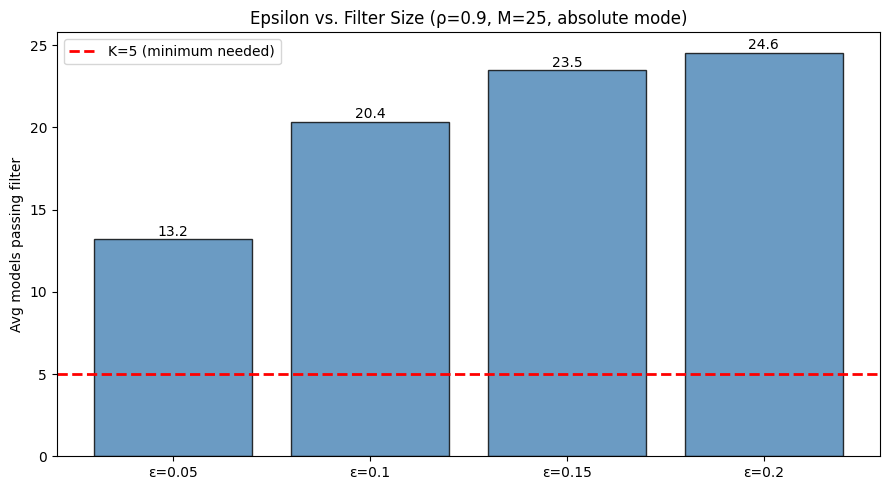

Fig 4: Bar chart of filtered model count vs. epsilon.
Dashed line at K=5. Any bar below this line will cause a warning.

For real datasets, use epsilon_mode='relative' — absolute epsilon depends on score scale.


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(range(len(EPSILON_VALUES)), eps_n_filtered, color="steelblue", edgecolor="black", alpha=0.8)
ax.axhline(K_fixed, color="red", linestyle="--", linewidth=2, label=f"K={K_fixed} (minimum needed)")
ax.set_xticks(range(len(EPSILON_VALUES)))
ax.set_xticklabels([f"\u03b5={e}" for e in EPSILON_VALUES])
ax.set_ylabel("Avg models passing filter")
ax.set_title(f"Epsilon vs. Filter Size (\u03c1={rho_fixed}, M={M_fixed}, absolute mode)")
ax.legend()

for i, v in enumerate(eps_n_filtered):
    ax.text(i, v + 0.2, f"{v:.1f}", ha="center", fontsize=10)

fig.tight_layout()
plt.show()
print("Fig 4: Bar chart of filtered model count vs. epsilon.")
print(f"Dashed line at K={K_fixed}. Any bar below this line will cause a warning.")
print("\nFor real datasets, use epsilon_mode='relative' \u2014 absolute epsilon depends on score scale.")

## Practical Tuning Guide

From the sweeps above, four rules:

**1. Starting configuration**
- Exploration: `M=50, K=10` — trains fast, results often sufficient for real data
- Publication: `M=200, K=30` — paper-quality stability, slower

**2. Real datasets: use relative epsilon**
```python
pipe = DASHPipeline(M=100, K=20, epsilon=0.05, epsilon_mode="relative", task="binary", ...)
```
`epsilon_mode="relative"` makes epsilon scale-invariant: 5% below best AUC works for AUC ∈ [0.7, 1.0]. `epsilon_mode="absolute"` is only reliable for synthetic data where you know the score range.

**3. Verify 2×K models pass the filter**
After fitting, check:
```python
print(f"Filtered: {len(pipe.filtered_indices_)} / {pipe.M} models passed (K={pipe.K})")
# Aim for >= 2*K
```
If fewer than 2×K models pass, increase epsilon or switch to `epsilon_mode="quantile"`.

**4. If stability isn't improving with larger K, increase M first**
More K only helps if the filtered pool is large enough. The plateau in the K sweep happens when you've exhausted the diverse candidates. Adding more M candidates gives MaxMin more options.

## Connection to Breast Cancer

The simulation explains the +0.614 stability improvement on Breast Cancer:

1. **ρ is very high**: 21 feature pairs with |r| > 0.9 means ρ≈0.95 for the worst pairs. The simulation shows this is where Single Best stability collapses most dramatically.

2. **Multiple collinear groups**: Breast Cancer doesn't just have one correlated pair — it has at least two distinct clusters (radius/size and concavity). Each cluster contributes independently to the instability.

3. **DASH's flat stability line** means it's equally reliable regardless of correlation level. This is why DASH works well on Breast Cancer even though we can't control ρ in real data.

The simulation is a controlled proof-of-concept for the mechanism. Breast Cancer shows the mechanism operating in real clinical data with real feature names.

For the full paper methodology with 9 methods and 50-rep estimates, see `EXPERIMENT_GUIDE.md` and run `python run_experiments_parallel.py`.